# Distance-dependent chromVAR analysis with constrained Gaussian processes

This notebook reproduces the all-condition chromVAR spatial screen using the
updated Perturb-Tags MuData object. It analyzes 15 ligand perturbations and
four pure-guide non-targeting controls.

For each condition, it:

1. measures the distance from an assigned, non-reference perturbation cell
   to the nearest reference cell **within the same embryoid body**;
2. forms 30 non-overlapping distance bins, `[0, 10), [10, 20), ...,
   [290, 300]` µm;
3. calculates arithmetic pseudobulk means and cell-IID SEMs for all 633
   signed chromVAR motif scores;
4. compares a fixed-noise Constant-kernel GP with a fixed-noise RBF GP;
5. optimizes the RBF variance and lengthscale from 30, 50, and 200 µm
   starts while imposing a scientifically chosen **minimum lengthscale of
   25 µm**; and
6. applies Benjamini-Hochberg (BH) FDR control separately within each
   condition, with Benjamini-Yekutieli (BY) reported as a sensitivity
   analysis.

The accepted reference run completed all 19 × 633 = 12,027 tests without a
fit failure. It found 78 BH-significant motifs for WNT5A, 1,162
ligand–motif discoveries in the sum of the 15 within-ligand BH analyses,
and 179 discoveries across the four within-control BH analyses.

“10 µm” refers to the width of the non-overlapping distance bins, rather
than to a cumulative-radius neighborhood.


## Setup

The validated environment used Python 3.12 with NumPy 1.26.4, SciPy
1.12.0, pandas 2.2.3, Matplotlib 3.10.0, h5py 3.16.0, GPy 1.13.2,
paramz 0.9.6, and joblib 1.5.3. An isolated environment is recommended
because GPy's NumPy/SciPy pins may conflict with newer single-cell
packages.

Set `INSTALL_DEPENDENCIES = True` once in a fresh isolated environment if
needed. The MuData file is intentionally not downloaded automatically:
point `PERTURB_TAGS_H5MU` to the updated local file. This avoids silently
substituting an older similarly named object.


In [1]:
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "numpy==1.26.4",
            "scipy==1.12.0",
            "pandas==2.2.3",
            "matplotlib==3.10.0",
            "h5py==3.16.0",
            "GPy==1.13.2",
            "paramz==0.9.6",
            "joblib==1.5.3",
            "ipykernel",
        ],
        check=True,
    )
else:
    print("Dependency installation skipped; using the active environment.")


Dependency installation skipped; using the active environment.


In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import re
import sys
import time
import warnings
import weakref
from dataclasses import dataclass
from importlib import metadata as importlib_metadata
from pathlib import Path

# Prevent nested BLAS threading inside parallel GP workers.
for variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "BLIS_NUM_THREADS",
    "GOTO_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ.setdefault(variable, "1")

import GPy
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from joblib import Parallel, delayed, parallel_config
from paramz.transformations import Logexp, Transformation
from scipy.spatial import KDTree
from scipy.stats import chi2

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 50)
mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 220,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

SOURCE_NAME = (
    "all_lanes_merged_CATATAC_QC_RNA_processed_"
    "EB_manual_clustering_cell_types.h5mu"
)
REFERENCE_SOURCE_SHA256 = (
    "b2baffb8c86e359ad4f3242f36f296fa3911f892fb0bda1f8528cb1654074750"
)
source_override = os.environ.get("PERTURB_TAGS_H5MU")
source_candidates = [
    Path(source_override) if source_override else None,
    Path("data") / SOURCE_NAME,
    Path(SOURCE_NAME),
    Path("..") / SOURCE_NAME,
]
H5MU_PATH = next(
    (
        path
        for path in source_candidates
        if path is not None and path.is_file()
    ),
    Path(source_override) if source_override else Path("data") / SOURCE_NAME,
)

output_override = os.environ.get("CHROMVAR_GP_OUTPUT_DIR")
OUTPUT_DIR = Path(
    output_override or "output/chromvar_gp_10um_min_l25"
).resolve()
precomputed_override = os.environ.get("CHROMVAR_GP_PRECOMPUTED_DIR")
PRECOMPUTED_DIR = (
    Path(precomputed_override).resolve()
    if precomputed_override
    else None
)
RESULTS_ROOT = PRECOMPUTED_DIR or OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_DISTANCE_UM = 300.0
BIN_WIDTH_UM = 10.0
N_BINS = 30
RBF_LENGTHSCALE_MINIMUM_UM = 25.0
RBF_STARTS_UM = (30.0, 50.0, 200.0)
MAX_OPTIMIZER_ITERS = 1000
FDR_THRESHOLD = 0.05
N_JOBS = int(os.environ.get("CHROMVAR_GP_WORKERS", min(6, os.cpu_count() or 1)))
FORCE_RECOMPUTE = os.environ.get("CHROMVAR_GP_FORCE", "0") == "1"
DISPLAY_ALL_TOP_FITS = (
    os.environ.get("CHROMVAR_GP_DISPLAY_ALL_TOP_FITS", "0") == "1"
)

print(f"MuData source: {H5MU_PATH}")
print(f"Results root: {RESULTS_ROOT}")
print(f"Parallel GP workers: {N_JOBS}")
print(
    f"GPy {GPy.__version__}; NumPy {np.__version__}; "
    f"SciPy {importlib_metadata.version('scipy')}"
)


MuData source: C:\Users\welchjd\OneDrive - Michigan Medicine\Desktop\StudentProjects\Javid\all_lanes_merged_CATATAC_QC_RNA_processed_EB_manual_clustering_cell_types.h5mu
Results root: C:\Users\welchjd\OneDrive - Michigan Medicine\Desktop\StudentProjects\Javid\results\chromvar_all_ligands_gp_assigned_10um_min_l25
Parallel GP workers: 6
GPy 1.13.2; NumPy 1.26.4; SciPy 1.12.0


## 1. Source data and alignment

The response matrix is `mod/chromvar/X`: one signed chromVAR deviation
score per cell and motif. No TF-IDF, log transform, centering, variance
normalization, detection filter, or abundance filter is applied.

The checks below ensure that root observations, chromVAR observations,
spatial coordinates, and motif annotations are aligned. The file checksum
identifies the exact updated object used for the accepted run.


In [3]:
def sha256_file(path: Path, block_bytes: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(block_bytes), b""):
            digest.update(block)
    return digest.hexdigest()


def decode_array(values) -> np.ndarray:
    return np.asarray(
        [
            value.decode("utf-8")
            if isinstance(value, (bytes, np.bytes_))
            else str(value)
            for value in values
        ],
        dtype=str,
    )


def read_encoded_strings(node) -> np.ndarray:
    if isinstance(node, h5py.Dataset):
        return decode_array(node[:])
    categories = decode_array(node["categories"][:])
    codes = np.asarray(node["codes"][:], dtype=np.int64)
    result = np.full(codes.shape, "", dtype=object)
    valid = codes >= 0
    result[valid] = categories[codes[valid]]
    return result.astype(str)


def read_nullable_strings(node) -> np.ndarray:
    mask = np.asarray(node["mask"][:], dtype=bool)
    if np.any(mask):
        raise ValueError(f"Missing motif strings in {node.name}.")
    return decode_array(node["values"][:])


def inspect_source(path: Path) -> dict:
    if not path.is_file():
        raise FileNotFoundError(
            f"Updated MuData file not found: {path}. "
            "Set PERTURB_TAGS_H5MU to its full path."
        )
    with h5py.File(path, "r") as handle:
        chromvar = handle["mod"]["chromvar"]
        score_data = chromvar["X"]
        root_names = read_encoded_strings(handle["obs"]["_index"])
        modality_names = read_encoded_strings(chromvar["obs"]["_index"])
        root_spatial = np.column_stack(
            [
                np.asarray(handle["obs"]["SPATIAL_1"][:], dtype=float),
                np.asarray(handle["obs"]["SPATIAL_2"][:], dtype=float),
            ]
        )
        modality_spatial = np.asarray(
            chromvar["obsm"]["X_spatial"][:], dtype=float
        )
        obsmap = np.asarray(handle["obsmap"]["chromvar"][:], dtype=np.int64)
        n_cells, n_motifs = map(int, score_data.shape)
        assert np.array_equal(root_names, modality_names)
        assert np.array_equal(root_spatial, modality_spatial)
        assert np.array_equal(
            obsmap, np.arange(1, n_cells + 1, dtype=np.int64)
        )
        motif_ids = read_nullable_strings(chromvar["var"]["motif_id"])
        motif_names = read_nullable_strings(chromvar["var"]["motif_name"])
        assert motif_ids.size == motif_names.size == n_motifs
        assert np.unique(motif_ids).size == n_motifs
        return {
            "cells": n_cells,
            "motifs": n_motifs,
            "score_dtype": str(score_data.dtype),
            "source_bytes": path.stat().st_size,
        }


source_metadata = inspect_source(H5MU_PATH)
source_sha256 = sha256_file(H5MU_PATH)
source_metadata["sha256"] = source_sha256
source_metadata["matches_accepted_source"] = (
    source_sha256 == REFERENCE_SOURCE_SHA256
)
display(pd.DataFrame(source_metadata.items(), columns=["quantity", "value"]))


,quantity,value
0,cells,17043
1,motifs,633
2,score_dtype,float64
3,source_bytes,615210049
4,sha256,b2baffb8c86e359ad4f3242f36f296fa3911f892fb0bda...
5,matches_accepted_source,True


## 2. Conditions, within-EB distances, and pseudobulk profiles

Ligand references are cells whose `target_call` equals that ligand.
Ligand query cells are cells assigned to a different perturbation;
`Unassigned`, `No_CRISPR_data`, and `Non-Targeting` cells are excluded.

Each NTC reference set contains pure cells carrying only the selected
`Negative control-N` guide (one or more copies separated by semicolons).
NTC query cells are assigned perturbation cells after excluding every
pure-NTC cell. Distances are always computed separately inside each EB.

Cells with any non-finite chromVAR value are removed after distance
assignment. Within each bin, the notebook computes the arithmetic mean
and population-SD (`ddof=0`) divided by √n. The fixed observation-noise
variance for a motif is the mean of its 30 squared SEMs.


In [4]:
@dataclass(frozen=True)
class Condition:
    dataset: str
    target: str
    reference_mode: str = "target_call"
    ntc_guide: str | None = None

    @property
    def is_negative_control(self) -> bool:
        return self.reference_mode == "pure_ntc_guide"

    @property
    def reference_selector(self) -> str:
        return self.ntc_guide or self.target


CONDITIONS = (
    Condition("WNT5A", "WNT5A"),
    Condition("WNT1", "WNT1"),
    Condition("BMP5", "BMP5"),
    Condition("BMP7", "BMP7"),
    Condition("JAG1", "JAG1"),
    Condition("DLL3", "DLL3"),
    Condition("VEGFB", "VEGFB"),
    Condition("PDGFC", "PDGFC"),
    Condition("EFNA3", "EFNA3"),
    Condition("RSPO3", "RSPO3"),
    Condition("SEMA6D", "SEMA6D"),
    Condition("NECTIN2", "NECTIN2"),
    Condition("NECTIN3", "NECTIN3"),
    Condition("ALB", "ALB"),
    Condition("B2M", "B2M"),
    Condition(
        "NTC_1", "Negative control-1", "pure_ntc_guide", "Negative control-1"
    ),
    Condition(
        "NTC_2", "Negative control-2", "pure_ntc_guide", "Negative control-2"
    ),
    Condition(
        "NTC_3", "Negative control-3", "pure_ntc_guide", "Negative control-3"
    ),
    Condition(
        "NTC_5", "Negative control-5", "pure_ntc_guide", "Negative control-5"
    ),
)
EXCLUDED_QUERY_LABELS = {
    "Unassigned",
    "No_CRISPR_data",
    "Non-Targeting",
}
PURE_NTC_PATTERN = re.compile(
    r"^(Negative control-\d+)(;Negative control-\d+)*$"
)


def load_source_arrays(path: Path) -> dict[str, np.ndarray]:
    with h5py.File(path, "r") as handle:
        chromvar = handle["mod"]["chromvar"]
        return {
            "scores": np.asarray(chromvar["X"][:], dtype=np.float64),
            "target_calls": read_encoded_strings(handle["obs"]["target_call"]),
            "eb_clusters": read_encoded_strings(
                handle["obs"]["EB_manual_clustering"]
            ),
            "spatial": np.column_stack(
                [
                    np.asarray(handle["obs"]["SPATIAL_1"][:], dtype=float),
                    np.asarray(handle["obs"]["SPATIAL_2"][:], dtype=float),
                ]
            ),
            "guides": read_encoded_strings(
                handle["obs"]["guides_passing_str"]
            ),
            "motif_ids": read_nullable_strings(
                chromvar["var"]["motif_id"]
            ),
            "motif_names": read_nullable_strings(
                chromvar["var"]["motif_name"]
            ),
            "motif_database": read_encoded_strings(
                chromvar["var"]["motif_database"]
            ),
            "motif_collection": read_encoded_strings(
                chromvar["var"]["motif_collection"]
            ),
            "species_taxon": np.asarray(
                chromvar["var"]["species_taxon"][:], dtype=np.int64
            ),
        }


def condition_masks(raw: dict, condition: Condition):
    target_calls = raw["target_calls"]
    if not condition.is_negative_control:
        reference = target_calls == condition.target
        query = np.asarray(
            [
                label not in EXCLUDED_QUERY_LABELS
                and label != condition.target
                for label in target_calls
            ],
            dtype=bool,
        )
    else:
        pure_ntc = np.asarray(
            [bool(PURE_NTC_PATTERN.fullmatch(value)) for value in raw["guides"]],
            dtype=bool,
        )
        reference = np.asarray(
            [
                is_pure
                and condition.reference_selector in value.split(";")
                for value, is_pure in zip(
                    raw["guides"], pure_ntc, strict=True
                )
            ],
            dtype=bool,
        )
        query = np.asarray(
            [
                label not in EXCLUDED_QUERY_LABELS
                for label in target_calls
            ],
            dtype=bool,
        )
        query &= ~pure_ntc
    assert np.any(reference)
    assert np.any(query)
    assert not np.any(reference & query)
    return reference, query


def within_eb_bin_ids(raw: dict, reference, query):
    distances = np.full(reference.size, np.inf, dtype=np.float64)
    covered_ebs = 0
    for eb in np.unique(raw["eb_clusters"]):
        in_eb = raw["eb_clusters"] == eb
        reference_in_eb = reference & in_eb
        query_in_eb = query & in_eb
        if not np.any(reference_in_eb) or not np.any(query_in_eb):
            continue
        distance, _ = KDTree(raw["spatial"][reference_in_eb]).query(
            raw["spatial"][query_in_eb]
        )
        distances[np.flatnonzero(query_in_eb)] = distance
        covered_ebs += 1

    bin_ids = np.full(reference.size, -1, dtype=np.int16)
    for index in range(N_BINS):
        lower = index * BIN_WIDTH_UM
        upper = (index + 1) * BIN_WIDTH_UM
        upper_test = (
            distances <= upper
            if index == N_BINS - 1
            else distances < upper
        )
        selected = (
            query
            & (distances >= lower)
            & upper_test
            & (distances <= MAX_DISTANCE_UM)
        )
        bin_ids[selected] = index
    return bin_ids, distances, covered_ebs


def prepare_condition(raw: dict, condition: Condition, dataset_dir: Path):
    reference, query = condition_masks(raw, condition)
    bin_ids, distances, covered_ebs = within_eb_bin_ids(
        raw, reference, query
    )
    counts_before = np.bincount(
        bin_ids[bin_ids >= 0].astype(np.int64), minlength=N_BINS
    )
    complete = np.all(np.isfinite(raw["scores"]), axis=1)
    bin_ids[(bin_ids >= 0) & ~complete] = -1
    bin_counts = np.bincount(
        bin_ids[bin_ids >= 0].astype(np.int64), minlength=N_BINS
    )
    if np.any(bin_counts < 2):
        raise ValueError(
            f"{condition.dataset} has a bin with fewer than two cells."
        )

    means = np.empty((N_BINS, raw["scores"].shape[1]), dtype=float)
    sems = np.empty_like(means)
    for index in range(N_BINS):
        values = raw["scores"][bin_ids == index]
        means[index] = values.mean(axis=0)
        sems[index] = values.std(axis=0, ddof=0) / np.sqrt(values.shape[0])
    mean_sem_sq = np.mean(np.square(sems), axis=0)
    valid = (
        np.all(np.isfinite(means), axis=0)
        & np.all(np.isfinite(sems), axis=0)
        & np.isfinite(mean_sem_sq)
        & (mean_sem_sq > 0)
    )
    selected = np.flatnonzero(valid)
    if selected.size != 633:
        raise ValueError(
            f"Expected 633 valid motifs for {condition.dataset}; "
            f"found {selected.size}."
        )
    X = (5.0 + BIN_WIDTH_UM * np.arange(N_BINS))[:, None]
    dataset_dir.mkdir(parents=True, exist_ok=True)
    input_path = dataset_dir / (
        f"{condition.dataset.lower()}_chromvar_inputs.npz"
    )
    np.savez_compressed(
        input_path,
        X=X,
        means=means[:, selected],
        sems=sems[:, selected],
        mean_sem_sq=mean_sem_sq[selected],
        detection=np.ones(selected.size),
        gene_names=raw["motif_ids"][selected],
        gene_indices=selected,
        bin_counts=bin_counts,
        bin_counts_before_complete_case=counts_before,
        motif_ids=raw["motif_ids"][selected],
        motif_names=raw["motif_names"][selected],
        motif_database=raw["motif_database"][selected],
        motif_collection=raw["motif_collection"][selected],
        species_taxon=raw["species_taxon"][selected],
    )
    summary = {
        "dataset": condition.dataset,
        "reference_cell_count": int(reference.sum()),
        "eligible_query_cell_count": int(query.sum()),
        "binned_query_cell_count_before_complete_case": int(
            counts_before.sum()
        ),
        "binned_query_cell_count": int(bin_counts.sum()),
        "embryoid_bodies_with_reference_and_query": int(covered_ebs),
        "bin_counts": bin_counts.tolist(),
        "input_npz": input_path.name,
    }
    (dataset_dir / "preprocessing_summary.json").write_text(
        json.dumps(summary, indent=2) + "\n", encoding="utf-8"
    )
    return input_path, summary


def read_condition_input(input_path: Path) -> dict[str, np.ndarray]:
    with np.load(input_path, allow_pickle=False) as archive:
        result = {name: archive[name] for name in archive.files}
    result["X"] = np.asarray(result["X"], dtype=float)
    result["means"] = np.asarray(result["means"], dtype=float)
    result["sems"] = np.asarray(result["sems"], dtype=float)
    result["mean_sem_sq"] = np.asarray(
        result["mean_sem_sq"], dtype=float
    )
    result["bin_counts"] = np.asarray(result["bin_counts"], dtype=int)
    result["motif_ids"] = np.asarray(
        result.get("motif_ids", result["gene_names"])
    ).astype(str)
    result["motif_names"] = np.asarray(result["motif_names"]).astype(str)
    assert result["X"].shape == (30, 1)
    assert result["means"].shape == result["sems"].shape == (30, 633)
    assert result["mean_sem_sq"].shape == (633,)
    assert np.allclose(
        result["mean_sem_sq"],
        np.mean(np.square(result["sems"]), axis=0),
        rtol=1e-10,
        atol=1e-14,
    )
    return result


In [5]:
def locate_cached_input(root: Path, condition: Condition):
    dataset_dir = root / "datasets" / condition.dataset
    candidates = sorted(dataset_dir.glob("*_chromvar_inputs.npz"))
    if len(candidates) == 1:
        summary_path = dataset_dir / "preprocessing_summary.json"
        summary = (
            json.loads(summary_path.read_text(encoding="utf-8"))
            if summary_path.is_file()
            else {}
        )
        return candidates[0], summary
    return None, None


inputs: dict[str, dict[str, np.ndarray]] = {}
preprocessing: dict[str, dict] = {}
missing_conditions = []
for condition in CONDITIONS:
    input_path, summary = locate_cached_input(RESULTS_ROOT, condition)
    if input_path is None or FORCE_RECOMPUTE:
        missing_conditions.append(condition)
    else:
        inputs[condition.dataset] = read_condition_input(input_path)
        preprocessing[condition.dataset] = summary

if missing_conditions:
    print(
        "Preparing cell-level chromVAR profiles for:",
        ", ".join(item.dataset for item in missing_conditions),
    )
    raw = load_source_arrays(H5MU_PATH)
    for condition in missing_conditions:
        dataset_dir = OUTPUT_DIR / "datasets" / condition.dataset
        input_path, summary = prepare_condition(raw, condition, dataset_dir)
        inputs[condition.dataset] = read_condition_input(input_path)
        preprocessing[condition.dataset] = summary
    del raw
else:
    print("Loaded all 19 validated binned inputs from the results cache.")

assert set(inputs) == {condition.dataset for condition in CONDITIONS}
assert all(item["motif_ids"].size == 633 for item in inputs.values())
wnt5a_bins = pd.DataFrame(
    {
        "lower_um": np.arange(N_BINS) * BIN_WIDTH_UM,
        "upper_um": (np.arange(N_BINS) + 1) * BIN_WIDTH_UM,
        "midpoint_um": inputs["WNT5A"]["X"][:, 0],
        "cell_count": inputs["WNT5A"]["bin_counts"],
    }
)
display(wnt5a_bins.T)


Loaded all 19 validated binned inputs from the results cache.


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
lower_um,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,100.0,110.0,120.0,130.0,140.0,150.0,160.0,170.0,180.0,190.0,200.0,210.0,220.0,230.0,240.0,250.0,260.0,270.0,280.0,290.0
upper_um,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,100.0,110.0,120.0,130.0,140.0,150.0,160.0,170.0,180.0,190.0,200.0,210.0,220.0,230.0,240.0,250.0,260.0,270.0,280.0,290.0,300.0
midpoint_um,5.0,15.0,25.0,35.0,45.0,55.0,65.0,75.0,85.0,95.0,105.0,115.0,125.0,135.0,145.0,155.0,165.0,175.0,185.0,195.0,205.0,215.0,225.0,235.0,245.0,255.0,265.0,275.0,285.0,295.0
cell_count,75.0,232.0,353.0,419.0,468.0,514.0,533.0,528.0,508.0,459.0,473.0,443.0,436.0,458.0,386.0,389.0,376.0,341.0,298.0,281.0,230.0,237.0,199.0,165.0,144.0,147.0,106.0,102.0,93.0,96.0


## 3. Fixed-noise Constant-versus-RBF likelihood-ratio screen

For each motif, both models are zero-mean GPy regressions with
`normalizer=False` and the same fixed scalar Gaussian-noise variance,
`mean(SEM²)` across the 30 bins. The null covariance is a Constant
(`GPy.kern.Bias`) kernel. The alternative is an RBF kernel whose variance
and lengthscale are optimized from 30, 50, and 200 µm starts; the
highest-likelihood start is retained.

The shifted-softplus transform below imposes the one-sided support
`lengthscale > 25 µm` without imposing an arbitrary upper bound. The
primary p-value is the approximate boundary mixture,
`0.5 × χ²₁ survival(LR)` for positive LR. BH is primary; BY and an
ordinary χ²₁ p-value are saved as sensitivities.

The notebook uses joblib's process backend so functions defined here can
be parallelized safely on Windows. Each process is restricted to one BLAS
thread.


In [6]:
class LowerBoundedLogexp(Transformation):
    domain = Logexp.domain
    _instances: list[weakref.ReferenceType] = []

    def __new__(cls, lower: float):
        cls._instances[:] = [
            ref for ref in cls._instances if ref() is not None
        ]
        for ref in cls._instances:
            instance = ref()
            if instance is not None and instance.lower == float(lower):
                return instance
        instance = object.__new__(cls)
        cls._instances.append(weakref.ref(instance))
        return instance

    def __init__(self, lower: float):
        self.lower = float(lower)
        self._softplus = Logexp()

    def _minimum_offset(self) -> float:
        return max(
            np.finfo(np.float64).eps
            * max(1.0, abs(self.lower))
            * 16.0,
            1e-8,
        )

    def _safe_offset(self, model_parameter):
        offset = np.asarray(model_parameter) - self.lower
        if np.any(offset < 0):
            raise ValueError("Parameter is below its lower bound.")
        return np.maximum(offset, self._minimum_offset())

    def f(self, optimizer_parameter):
        return self.lower + self._softplus.f(optimizer_parameter)

    def finv(self, model_parameter):
        return self._softplus.finv(self._safe_offset(model_parameter))

    def gradfactor(self, model_parameter, model_gradient):
        return self._softplus.gradfactor(
            self._safe_offset(model_parameter), model_gradient
        )

    def initialize(self, model_parameter):
        values = np.asarray(model_parameter)
        return np.where(
            values <= self.lower,
            self.lower + self._minimum_offset(),
            values,
        )

    def log_jacobian(self, model_parameter):
        return self._softplus.log_jacobian(
            self._safe_offset(model_parameter)
        )

    def log_jacobian_grad(self, model_parameter):
        return self._softplus.log_jacobian_grad(
            self._safe_offset(model_parameter)
        )

    def __str__(self):
        return f">{self.lower:g}"

    def __reduce__(self):
        return (self.__class__, (self.lower,))


def scalar(value) -> float:
    array = np.asarray(value, dtype=float).reshape(-1)
    if array.size != 1:
        raise ValueError(f"Expected scalar; found {array.shape}.")
    return float(array[0])


def fit_gp(
    X,
    y,
    noise_variance,
    *,
    kernel_kind,
    initial_lengthscale=None,
    minimum_lengthscale=None,
):
    signal_variance = max(
        float(np.mean(np.square(y))), float(noise_variance), 1e-12
    )
    if kernel_kind == "constant":
        kernel = GPy.kern.Bias(input_dim=1, variance=signal_variance)
    elif kernel_kind == "rbf":
        kernel = GPy.kern.RBF(
            input_dim=1,
            variance=signal_variance,
            lengthscale=float(initial_lengthscale),
        )
    else:
        raise ValueError(kernel_kind)
    model = GPy.models.GPRegression(
        np.ascontiguousarray(X, dtype=float),
        np.asarray(y, dtype=float).reshape(-1, 1),
        kernel=kernel,
        noise_var=float(noise_variance),
        normalizer=False,
    )
    model.Gaussian_noise.variance.fix(float(noise_variance))
    if minimum_lengthscale is not None:
        model.kern.lengthscale.unconstrain()
        model.kern.lengthscale.constrain(
            LowerBoundedLogexp(float(minimum_lengthscale))
        )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", RuntimeWarning)
        optimizer = model.optimize(
            optimizer="lbfgsb",
            messages=False,
            max_iters=MAX_OPTIMIZER_ITERS,
        )
    result = {
        "log_likelihood": float(model.log_likelihood()),
        "variance": scalar(model.kern.variance),
        "lengthscale": (
            scalar(model.kern.lengthscale)
            if kernel_kind == "rbf"
            else np.nan
        ),
        "optimizer_status": str(
            getattr(optimizer, "status", "unknown")
        ),
        "optimizer_function_evaluations": int(
            getattr(optimizer, "funct_eval", -1)
        ),
        "runtime_warnings": " | ".join(
            sorted(
                {
                    f"{item.category.__name__}: {item.message}"
                    for item in caught
                    if issubclass(item.category, RuntimeWarning)
                }
            )
        ),
    }
    assert scalar(model.Gaussian_noise.variance) == float(noise_variance)
    assert result["variance"] > 0
    if kernel_kind == "rbf":
        assert result["lengthscale"] >= float(minimum_lengthscale)
    return result


def fit_motif(position, X, y, noise_variance):
    try:
        constant = fit_gp(
            X,
            y,
            noise_variance,
            kernel_kind="constant",
        )
        alternatives = []
        errors = []
        for start in RBF_STARTS_UM:
            try:
                fitted = fit_gp(
                    X,
                    y,
                    noise_variance,
                    kernel_kind="rbf",
                    initial_lengthscale=start,
                    minimum_lengthscale=RBF_LENGTHSCALE_MINIMUM_UM,
                )
                fitted["initial_lengthscale"] = start
                alternatives.append(fitted)
            except Exception as exc:
                errors.append(
                    f"start={start:g}: {type(exc).__name__}: {exc}"
                )
        if not alternatives:
            raise RuntimeError("All RBF starts failed: " + " | ".join(errors))
        rbf = max(
            alternatives, key=lambda item: item["log_likelihood"]
        )
        raw_lr = 2.0 * (
            rbf["log_likelihood"] - constant["log_likelihood"]
        )
        lr = max(0.0, raw_lr)
        chi1_p = float(chi2.sf(lr, df=1)) if lr > 0 else 1.0
        boundary_p = 0.5 * chi1_p if lr > 0 else 1.0
        return {
            "input_gene_position": int(position),
            "fit_success": True,
            "constant_log_likelihood": constant["log_likelihood"],
            "constant_kernel_variance": constant["variance"],
            "constant_optimizer_status": constant["optimizer_status"],
            "rbf_log_likelihood": rbf["log_likelihood"],
            "rbf_kernel_variance": rbf["variance"],
            "rbf_lengthscale_um": rbf["lengthscale"],
            "rbf_selected_initial_lengthscale_um": rbf[
                "initial_lengthscale"
            ],
            "rbf_lengthscale_minimum_um": (
                RBF_LENGTHSCALE_MINIMUM_UM
            ),
            "rbf_optimizer_status": rbf["optimizer_status"],
            "rbf_successful_start_count": len(alternatives),
            "rbf_converged_start_count": sum(
                item["optimizer_status"].lower() == "converged"
                for item in alternatives
            ),
            "rbf_failed_start_count": len(errors),
            "rbf_start_errors": " | ".join(errors),
            "raw_likelihood_ratio": raw_lr,
            "likelihood_ratio_statistic": lr,
            "p_value": boundary_p,
            "p_value_chi_square_1_sensitivity": chi1_p,
            "fixed_noise_variance": float(noise_variance),
            "runtime_warnings": " | ".join(
                sorted(
                    {
                        message
                        for message in [
                            constant["runtime_warnings"],
                            *(
                                item["runtime_warnings"]
                                for item in alternatives
                            ),
                        ]
                        if message
                    }
                )
            ),
            "error": "",
        }
    except Exception as exc:
        return {
            "input_gene_position": int(position),
            "fit_success": False,
            "p_value": 1.0,
            "p_value_chi_square_1_sensitivity": 1.0,
            "fixed_noise_variance": float(noise_variance),
            "error": f"{type(exc).__name__}: {exc}",
        }


def adjusted_p_values(p_values, *, by=False):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values, kind="mergesort")
    ranked = values[order]
    ranks = np.arange(1, ranked.size + 1, dtype=float)
    factor = (
        np.sum(1.0 / ranks) if by else 1.0
    )
    ranked_adjusted = ranked * ranked.size * factor / ranks
    ranked_adjusted = np.minimum.accumulate(
        ranked_adjusted[::-1]
    )[::-1]
    restored = np.empty_like(ranked_adjusted)
    restored[order] = np.clip(ranked_adjusted, 0.0, 1.0)
    return restored


def annotate_screen(rows, data):
    table = pd.DataFrame(rows).sort_values("input_gene_position")
    positions = table["input_gene_position"].to_numpy(dtype=int)
    table["gene"] = data["motif_ids"][positions]
    table["motif_id"] = data["motif_ids"][positions]
    table["motif_name"] = data["motif_names"][positions]
    table["motif_label"] = [
        f"{name} ({motif})"
        for name, motif in zip(
            table["motif_name"], table["motif_id"], strict=True
        )
    ]
    table["mean_sem_sq"] = data["mean_sem_sq"][positions]
    table["average_sem"] = data["sems"][:, positions].mean(axis=0)
    table["mean_chromvar_score"] = data["means"][:, positions].mean(
        axis=0
    )
    table["chromvar_score_range"] = np.ptp(
        data["means"][:, positions], axis=0
    )
    successful = table["fit_success"].astype(bool)
    table["fdr_q_value"] = np.nan
    table["by_q_value_sensitivity"] = np.nan
    table["chi_square_1_bh_q_value_sensitivity"] = np.nan
    table.loc[successful, "fdr_q_value"] = adjusted_p_values(
        table.loc[successful, "p_value"]
    )
    table.loc[
        successful, "by_q_value_sensitivity"
    ] = adjusted_p_values(
        table.loc[successful, "p_value"], by=True
    )
    table.loc[
        successful, "chi_square_1_bh_q_value_sensitivity"
    ] = adjusted_p_values(
        table.loc[
            successful, "p_value_chi_square_1_sensitivity"
        ]
    )
    tolerance = max(
        1e-8, RBF_LENGTHSCALE_MINIMUM_UM * 1e-6
    )
    table["rbf_lengthscale_at_minimum"] = (
        table["rbf_lengthscale_um"]
        <= RBF_LENGTHSCALE_MINIMUM_UM + tolerance
    )
    table["significant_fdr"] = (
        table["fit_success"].astype(bool)
        & (table["fdr_q_value"] <= FDR_THRESHOLD)
    )
    table["significant_by_sensitivity"] = (
        table["fit_success"].astype(bool)
        & (table["by_q_value_sensitivity"] <= FDR_THRESHOLD)
    )
    return table


In [7]:
def cached_screen_path(root: Path, dataset: str) -> Path:
    return (
        root
        / "datasets"
        / dataset
        / "01_spatial_motif_screen"
        / "spatial_motif_lrt_results.tsv"
    )


results_by_dataset: dict[str, pd.DataFrame] = {}
screen_started = time.perf_counter()
for condition in CONDITIONS:
    cache_path = cached_screen_path(RESULTS_ROOT, condition.dataset)
    if cache_path.is_file() and not FORCE_RECOMPUTE:
        table = pd.read_csv(cache_path, sep="\t")
        print(
            f"{condition.dataset:7s}: loaded {table.shape[0]} cached fits"
        )
    else:
        data = inputs[condition.dataset]
        print(
            f"{condition.dataset:7s}: fitting 633 motifs with "
            f"{N_JOBS} workers..."
        )
        with parallel_config(
            backend="loky", inner_max_num_threads=1
        ):
            rows = Parallel(
                n_jobs=N_JOBS,
                batch_size=10,
                verbose=0,
            )(
                delayed(fit_motif)(
                    position,
                    data["X"],
                    data["means"][:, position],
                    data["mean_sem_sq"][position],
                )
                for position in range(633)
            )
        table = annotate_screen(rows, data)
        cache_path = cached_screen_path(
            OUTPUT_DIR, condition.dataset
        )
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        table.to_csv(
            cache_path, sep="\t", index=False, float_format="%.12g"
        )
    results_by_dataset[condition.dataset] = table

screen_elapsed = time.perf_counter() - screen_started
print(f"Screen loading/fitting elapsed: {screen_elapsed:.1f} seconds")


WNT5A  : loaded 633 cached fits
WNT1   : loaded 633 cached fits
BMP5   : loaded 633 cached fits
BMP7   : loaded 633 cached fits
JAG1   : loaded 633 cached fits
DLL3   : loaded 633 cached fits
VEGFB  : loaded 633 cached fits
PDGFC  : loaded 633 cached fits
EFNA3  : loaded 633 cached fits
RSPO3  : loaded 633 cached fits
SEMA6D : loaded 633 cached fits
NECTIN2: loaded 633 cached fits
NECTIN3: loaded 633 cached fits
ALB    : loaded 633 cached fits
B2M    : loaded 633 cached fits
NTC_1  : loaded 633 cached fits


NTC_2  : loaded 633 cached fits
NTC_3  : loaded 633 cached fits
NTC_5  : loaded 633 cached fits
Screen loading/fitting elapsed: 0.1 seconds


## 4. Combine conditions and control the FDR

BH and BY are calculated within each 633-motif condition. The notebook
also reports batch-wide corrections across all 19 conditions and across
the 15 ligands only; these are supplementary and do not replace the
prespecified within-condition results.

Direction is summarized as the bin-count-weighted mean at 250–300 µm
minus the corresponding mean at 0–50 µm.


In [8]:
def bool_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False})
        .fillna(False)
    )


combined_path = RESULTS_ROOT / "combined_motif_results.tsv"
summary_path = RESULTS_ROOT / "batch_summary.tsv"
if (
    combined_path.is_file()
    and summary_path.is_file()
    and not FORCE_RECOMPUTE
):
    combined = pd.read_csv(combined_path, sep="\t")
    batch_summary = pd.read_csv(summary_path, sep="\t")
else:
    combined_parts = []
    summary_rows = []
    for order, condition in enumerate(CONDITIONS, start=1):
        table = results_by_dataset[condition.dataset].copy()
        data = inputs[condition.dataset]
        positions = table["input_gene_position"].to_numpy(dtype=int)
        near = np.average(
            data["means"][data["X"][:, 0] < 50],
            axis=0,
            weights=data["bin_counts"][data["X"][:, 0] < 50],
        )
        far = np.average(
            data["means"][data["X"][:, 0] >= 250],
            axis=0,
            weights=data["bin_counts"][data["X"][:, 0] >= 250],
        )
        table["dataset"] = condition.dataset
        table["target"] = condition.target
        table["is_negative_control"] = condition.is_negative_control
        table["pooled_mean_0_50um"] = near[positions]
        table["pooled_mean_250_300um"] = far[positions]
        table["far_minus_near_chromvar"] = (
            far[positions] - near[positions]
        )
        table["spatial_direction"] = np.where(
            table["far_minus_near_chromvar"] > 0,
            "higher_far",
            np.where(
                table["far_minus_near_chromvar"] < 0,
                "higher_near",
                "flat",
            ),
        )
        combined_parts.append(table)
        prep = preprocessing[condition.dataset]
        summary_rows.append(
            {
                "order": order,
                "dataset": condition.dataset,
                "is_negative_control": (
                    condition.is_negative_control
                ),
                "reference_cell_count": prep.get(
                    "reference_cell_count", np.nan
                ),
                "binned_query_cell_count": prep.get(
                    "binned_query_cell_count",
                    int(data["bin_counts"].sum()),
                ),
                "tested_motif_count": table.shape[0],
                "fit_failure_count": int(
                    (~bool_series(table["fit_success"])).sum()
                ),
                "bh_fdr_0_05_motif_count": int(
                    bool_series(table["significant_fdr"]).sum()
                ),
                "by_fdr_0_05_motif_count": int(
                    bool_series(
                        table["significant_by_sensitivity"]
                    ).sum()
                ),
                "lengthscale_at_minimum_count": int(
                    bool_series(
                        table["rbf_lengthscale_at_minimum"]
                    ).sum()
                ),
                "significant_lengthscale_at_minimum_count": int(
                    (
                        bool_series(table["significant_fdr"])
                        & bool_series(
                            table["rbf_lengthscale_at_minimum"]
                        )
                    ).sum()
                ),
            }
        )
    combined = pd.concat(combined_parts, ignore_index=True)
    successful = bool_series(combined["fit_success"])
    ligand = ~bool_series(combined["is_negative_control"])
    combined["global_bh_q_all_19"] = np.nan
    combined["global_by_q_all_19"] = np.nan
    combined["global_bh_q_ligands_15"] = np.nan
    combined["global_by_q_ligands_15"] = np.nan
    combined.loc[
        successful, "global_bh_q_all_19"
    ] = adjusted_p_values(combined.loc[successful, "p_value"])
    combined.loc[
        successful, "global_by_q_all_19"
    ] = adjusted_p_values(
        combined.loc[successful, "p_value"], by=True
    )
    ligand_successful = successful & ligand
    combined.loc[
        ligand_successful, "global_bh_q_ligands_15"
    ] = adjusted_p_values(
        combined.loc[ligand_successful, "p_value"]
    )
    combined.loc[
        ligand_successful, "global_by_q_ligands_15"
    ] = adjusted_p_values(
        combined.loc[ligand_successful, "p_value"], by=True
    )
    batch_summary = pd.DataFrame(summary_rows)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    combined.to_csv(
        OUTPUT_DIR / "combined_motif_results.tsv",
        sep="\t",
        index=False,
        float_format="%.12g",
    )
    batch_summary.to_csv(
        OUTPUT_DIR / "batch_summary.tsv", sep="\t", index=False
    )

count_columns = [
    "dataset",
    "is_negative_control",
    "reference_cell_count",
    "binned_query_cell_count",
    "bh_fdr_0_05_motif_count",
    "by_fdr_0_05_motif_count",
    "lengthscale_at_minimum_count",
    "significant_lengthscale_at_minimum_count",
]
display(batch_summary[count_columns])


,dataset,is_negative_control,reference_cell_count,binned_query_cell_count,bh_fdr_0_05_motif_count,by_fdr_0_05_motif_count,lengthscale_at_minimum_count,significant_lengthscale_at_minimum_count
0,WNT5A,False,403,9489,78,7,56,15
1,WNT1,False,233,8079,14,4,58,4
2,BMP5,False,566,9903,136,62,66,20
3,BMP7,False,544,10012,30,4,65,2
4,JAG1,False,164,7438,1,0,49,0
5,DLL3,False,307,9034,24,7,35,2
6,VEGFB,False,646,10069,66,29,66,10
7,PDGFC,False,365,8912,242,173,40,19
8,EFNA3,False,491,9715,97,28,44,7
9,RSPO3,False,466,9625,31,11,59,4


## 5. Significant-motif counts and top GP fits

The count plot separates primary BH calls from the more conservative BY
sensitivity analysis. Each top-fit panel shows the binned mean ± SEM,
the optimized RBF posterior mean, and the **95% posterior predictive
interval** (`include_likelihood=True`), which includes the fixed
observation-noise variance.

The code creates one top-ten plot per condition. To keep the checked-in
notebook compact, WNT5A is displayed by default; set
`CHROMVAR_GP_DISPLAY_ALL_TOP_FITS=1` before launching Jupyter to display
all 19.


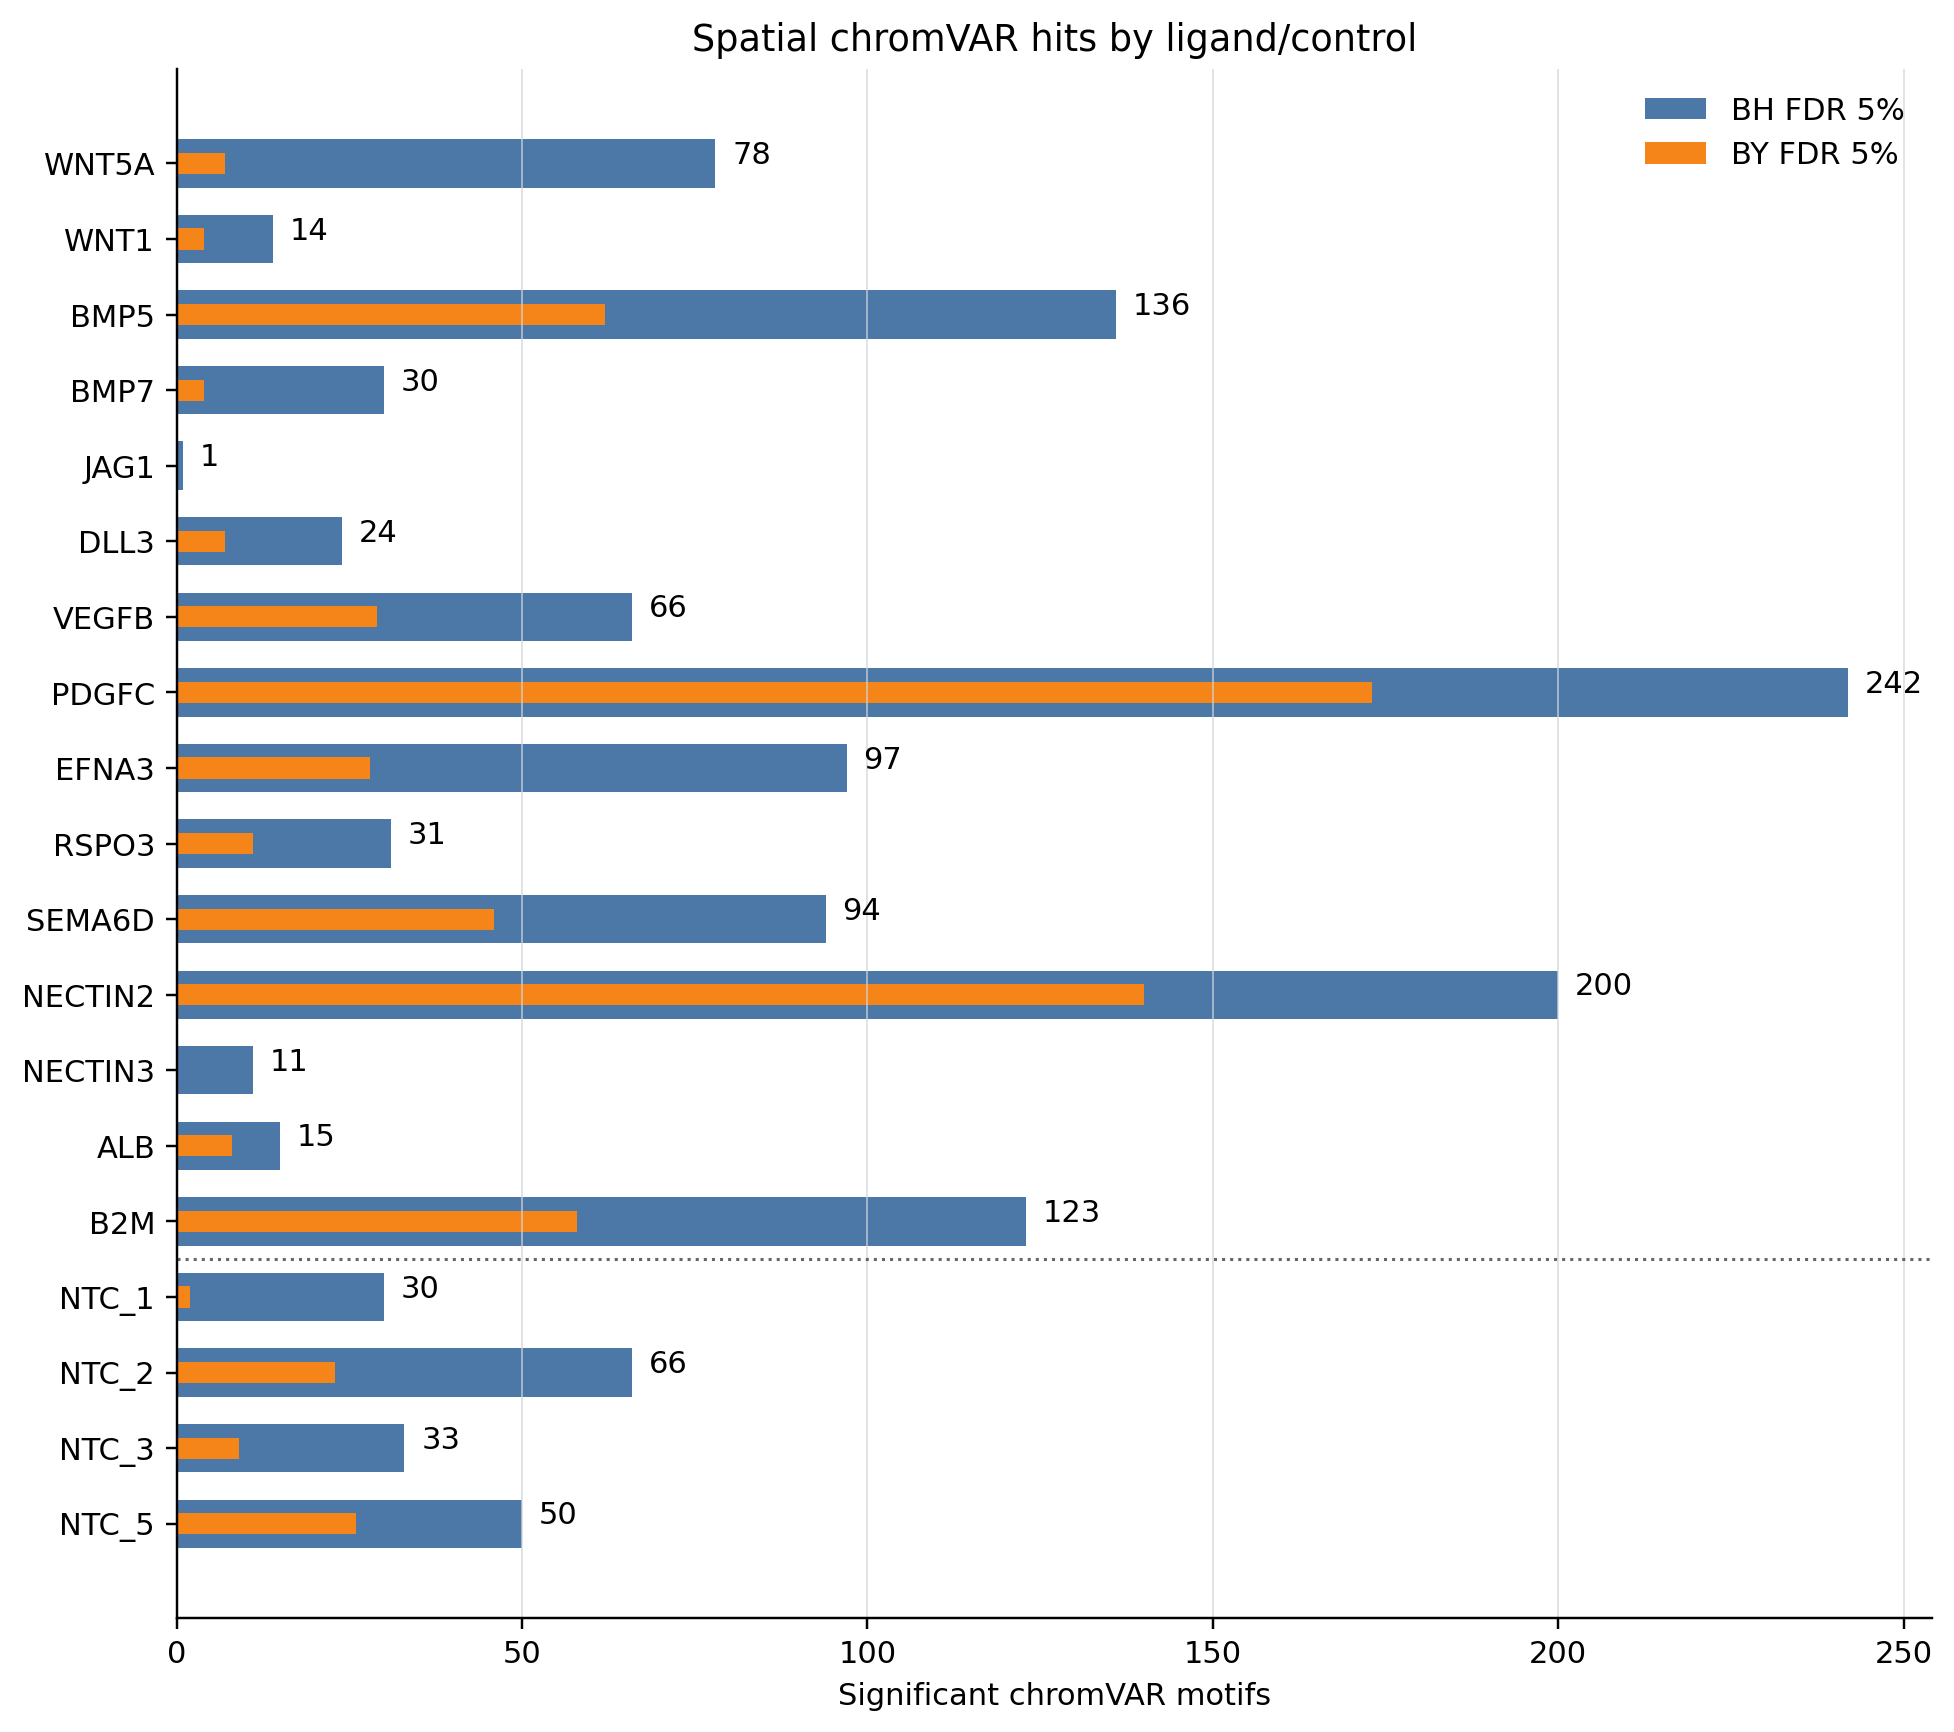

In [9]:
def plot_significant_counts(summary, output_dir: Path):
    labels = summary["dataset"].astype(str).tolist()
    y = np.arange(len(labels))
    bh = summary["bh_fdr_0_05_motif_count"].to_numpy(dtype=float)
    by = summary["by_fdr_0_05_motif_count"].to_numpy(dtype=float)
    figure, axis = plt.subplots(figsize=(9, 8))
    axis.barh(y, bh, height=0.64, color="#4C78A8", label="BH FDR 5%")
    axis.barh(y, by, height=0.28, color="#F58518", label="BY FDR 5%")
    for index, value in enumerate(bh):
        axis.text(
            value + max(1.0, bh.max() * 0.01),
            index,
            f"{int(value)}",
            va="center",
            fontsize=8,
        )
    axis.set_yticks(y, labels)
    axis.invert_yaxis()
    axis.axhline(14.5, color="#666666", linestyle=":", linewidth=1)
    axis.set_xlabel("Significant chromVAR motifs")
    axis.set_title(
        "Spatial chromVAR hits: 10 µm bins, RBF lengthscale ≥25 µm"
    )
    axis.grid(axis="x", color="#D1D5DB", linewidth=0.6, alpha=0.7)
    axis.legend(frameon=False)
    figure.tight_layout()
    output_dir.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        output_dir / "significant_motif_counts.png",
        dpi=220,
        bbox_inches="tight",
    )
    figure.savefig(
        output_dir / "significant_motif_counts.pdf",
        bbox_inches="tight",
    )
    return figure


existing_count_plot = RESULTS_ROOT / "significant_motif_counts.png"
if existing_count_plot.is_file() and not FORCE_RECOMPUTE:
    display(Image(filename=str(existing_count_plot)))
else:
    display(plot_significant_counts(batch_summary, OUTPUT_DIR))
    plt.close()


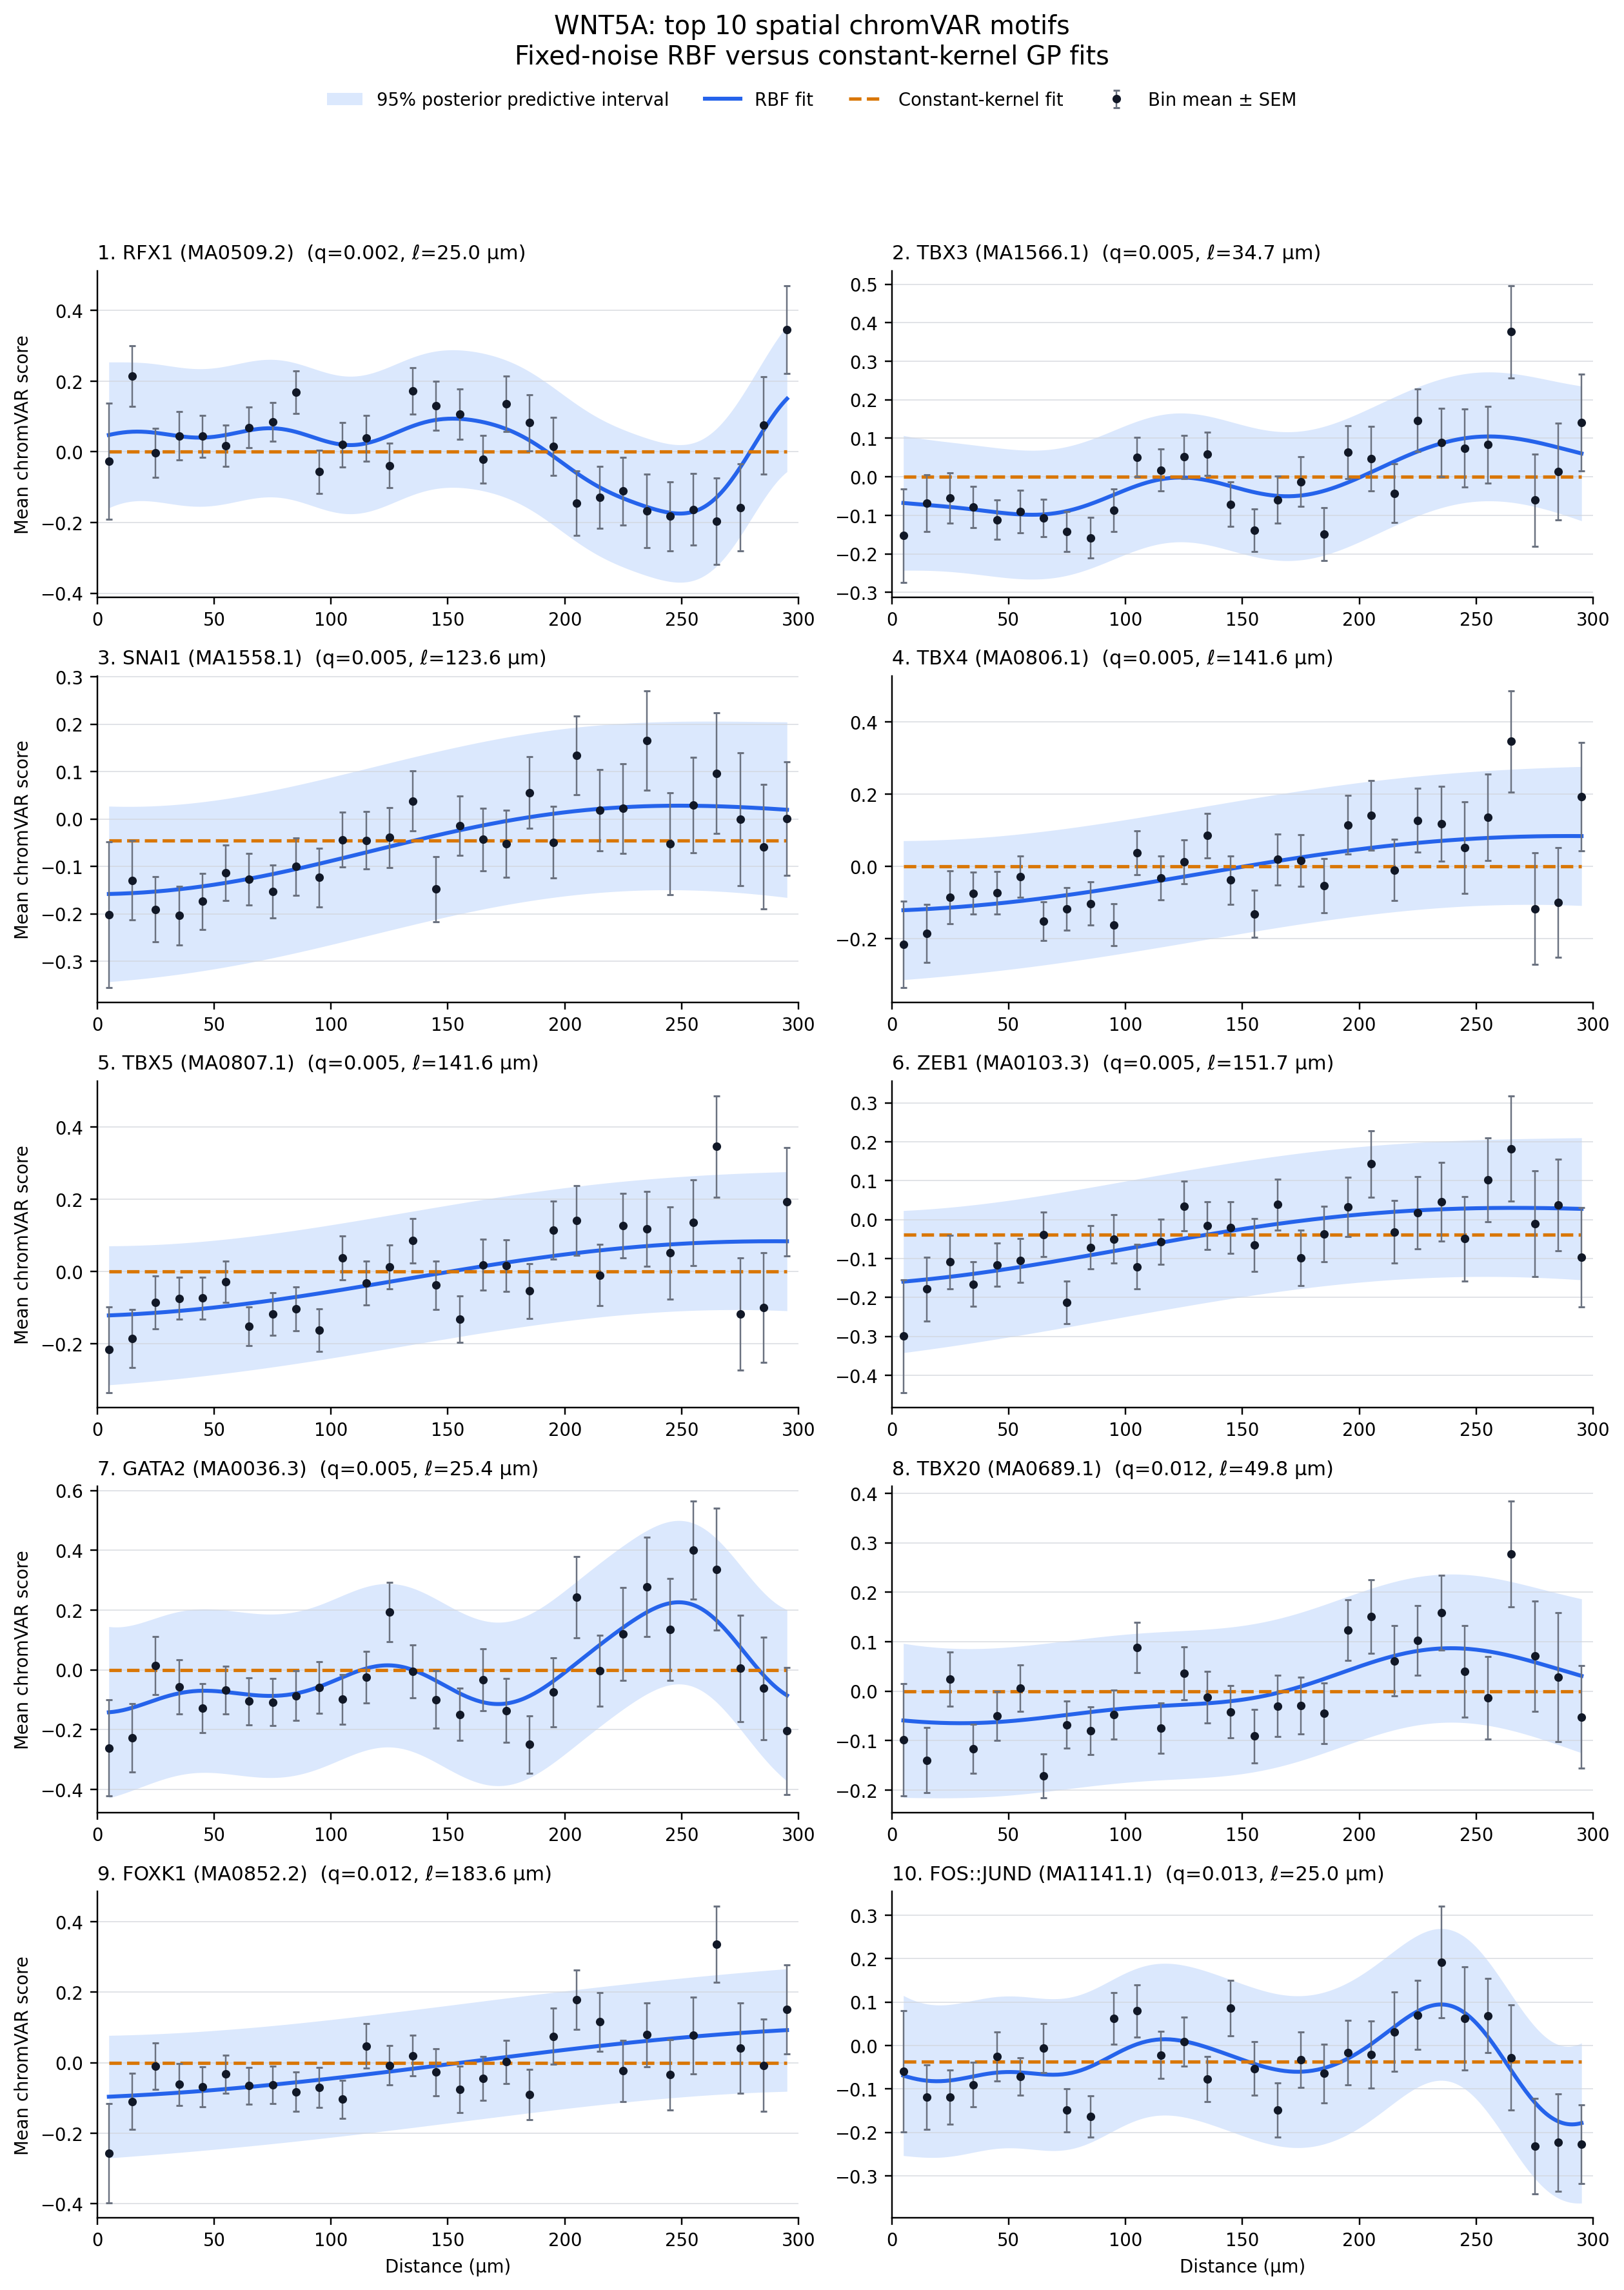

In [10]:
def build_fitted_model(data, row):
    position = int(row["input_gene_position"])
    kernel = GPy.kern.RBF(
        input_dim=1,
        variance=float(row["rbf_kernel_variance"]),
        lengthscale=float(row["rbf_lengthscale_um"]),
    )
    model = GPy.models.GPRegression(
        data["X"],
        data["means"][:, position, None],
        kernel=kernel,
        noise_var=float(row["fixed_noise_variance"]),
        normalizer=False,
    )
    model.Gaussian_noise.variance.fix(
        float(row["fixed_noise_variance"])
    )
    return model


def plot_top_fits(dataset, data, table, output_dir: Path):
    significant = table.loc[bool_series(table["significant_fdr"])].copy()
    selected = (
        significant
        if not significant.empty
        else table.loc[bool_series(table["fit_success"])].copy()
    )
    selected = selected.sort_values(
        ["fdr_q_value", "p_value", "likelihood_ratio_statistic"],
        ascending=[True, True, False],
        kind="mergesort",
    ).head(10)
    x_grid = np.linspace(0, 300, 601)[:, None]
    figure, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
    for axis, (_, row) in zip(axes.flat, selected.iterrows(), strict=False):
        position = int(row["input_gene_position"])
        model = build_fitted_model(data, row)
        mean, variance = model.predict(
            x_grid, include_likelihood=True
        )
        sd = np.sqrt(np.maximum(variance[:, 0], 0))
        axis.fill_between(
            x_grid[:, 0],
            mean[:, 0] - 1.96 * sd,
            mean[:, 0] + 1.96 * sd,
            color="#4C78A8",
            alpha=0.22,
            label="95% posterior predictive interval",
        )
        axis.plot(
            x_grid[:, 0],
            mean[:, 0],
            color="#1F4E79",
            linewidth=2.2,
            label="RBF GP",
        )
        axis.errorbar(
            data["X"][:, 0],
            data["means"][:, position],
            yerr=data["sems"][:, position],
            fmt="o",
            markersize=3.5,
            color="black",
            ecolor="#666666",
            capsize=2,
            linewidth=0.9,
            label="Mean ± SEM",
        )
        axis.set_title(
            f"{row['motif_name']} ({row['motif_id']})\n"
            f"BH q={row['fdr_q_value']:.2g}, "
            f"LR={row['likelihood_ratio_statistic']:.1f}, "
            f"ℓ={row['rbf_lengthscale_um']:.1f} µm",
            fontsize=10,
        )
        axis.grid(alpha=0.2)
    for axis in axes[1]:
        axis.set_xlabel("Distance to nearest reference cell (µm)")
    for axis in axes[:, 0]:
        axis.set_ylabel("Mean chromVAR score")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
    )
    figure.suptitle(
        f"{dataset}: distance-dependent chromVAR motif activity",
        fontsize=16,
        y=1.01,
    )
    figure.tight_layout(rect=(0, 0.07, 1, 0.97))
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = (
        "top10_significant_spatial_motif_gp_fits_predictive"
    )
    figure.savefig(
        output_dir / f"{stem}.png", dpi=220, bbox_inches="tight"
    )
    figure.savefig(
        output_dir / f"{stem}.pdf", bbox_inches="tight"
    )
    return figure


datasets_to_display = (
    [item.dataset for item in CONDITIONS]
    if DISPLAY_ALL_TOP_FITS
    else ["WNT5A"]
)
for dataset in datasets_to_display:
    existing = (
        RESULTS_ROOT
        / "datasets"
        / dataset
        / "01_spatial_motif_screen"
        / "top10_significant_spatial_motif_gp_fits_predictive.png"
    )
    if existing.is_file() and not FORCE_RECOMPUTE:
        display(Image(filename=str(existing)))
    else:
        figure = plot_top_fits(
            dataset,
            inputs[dataset],
            results_by_dataset[dataset],
            OUTPUT_DIR
            / "datasets"
            / dataset
            / "01_spatial_motif_screen",
        )
        display(figure)
        plt.close(figure)


## 6. Cross-condition recurrence and negative-control calibration

A motif is called recurrent ligand-associated when it is BH-significant
in at least two ligands, has a consistent near-versus-far direction, and
is not BH-significant in any of the four NTC analyses. The heatmap shows
the 25 most recurrent motifs using signed `−log10(BH q)`: red indicates
higher activity far from reference cells, and blue indicates higher
activity near them.

NTC discoveries are retained as a calibration warning rather than removed
automatically. The combined table allows downstream analyses to apply
alternative control-overlap rules.


Recurrent ligand-associated motifs: 134
Distinct motifs BH-significant in any NTC: 151


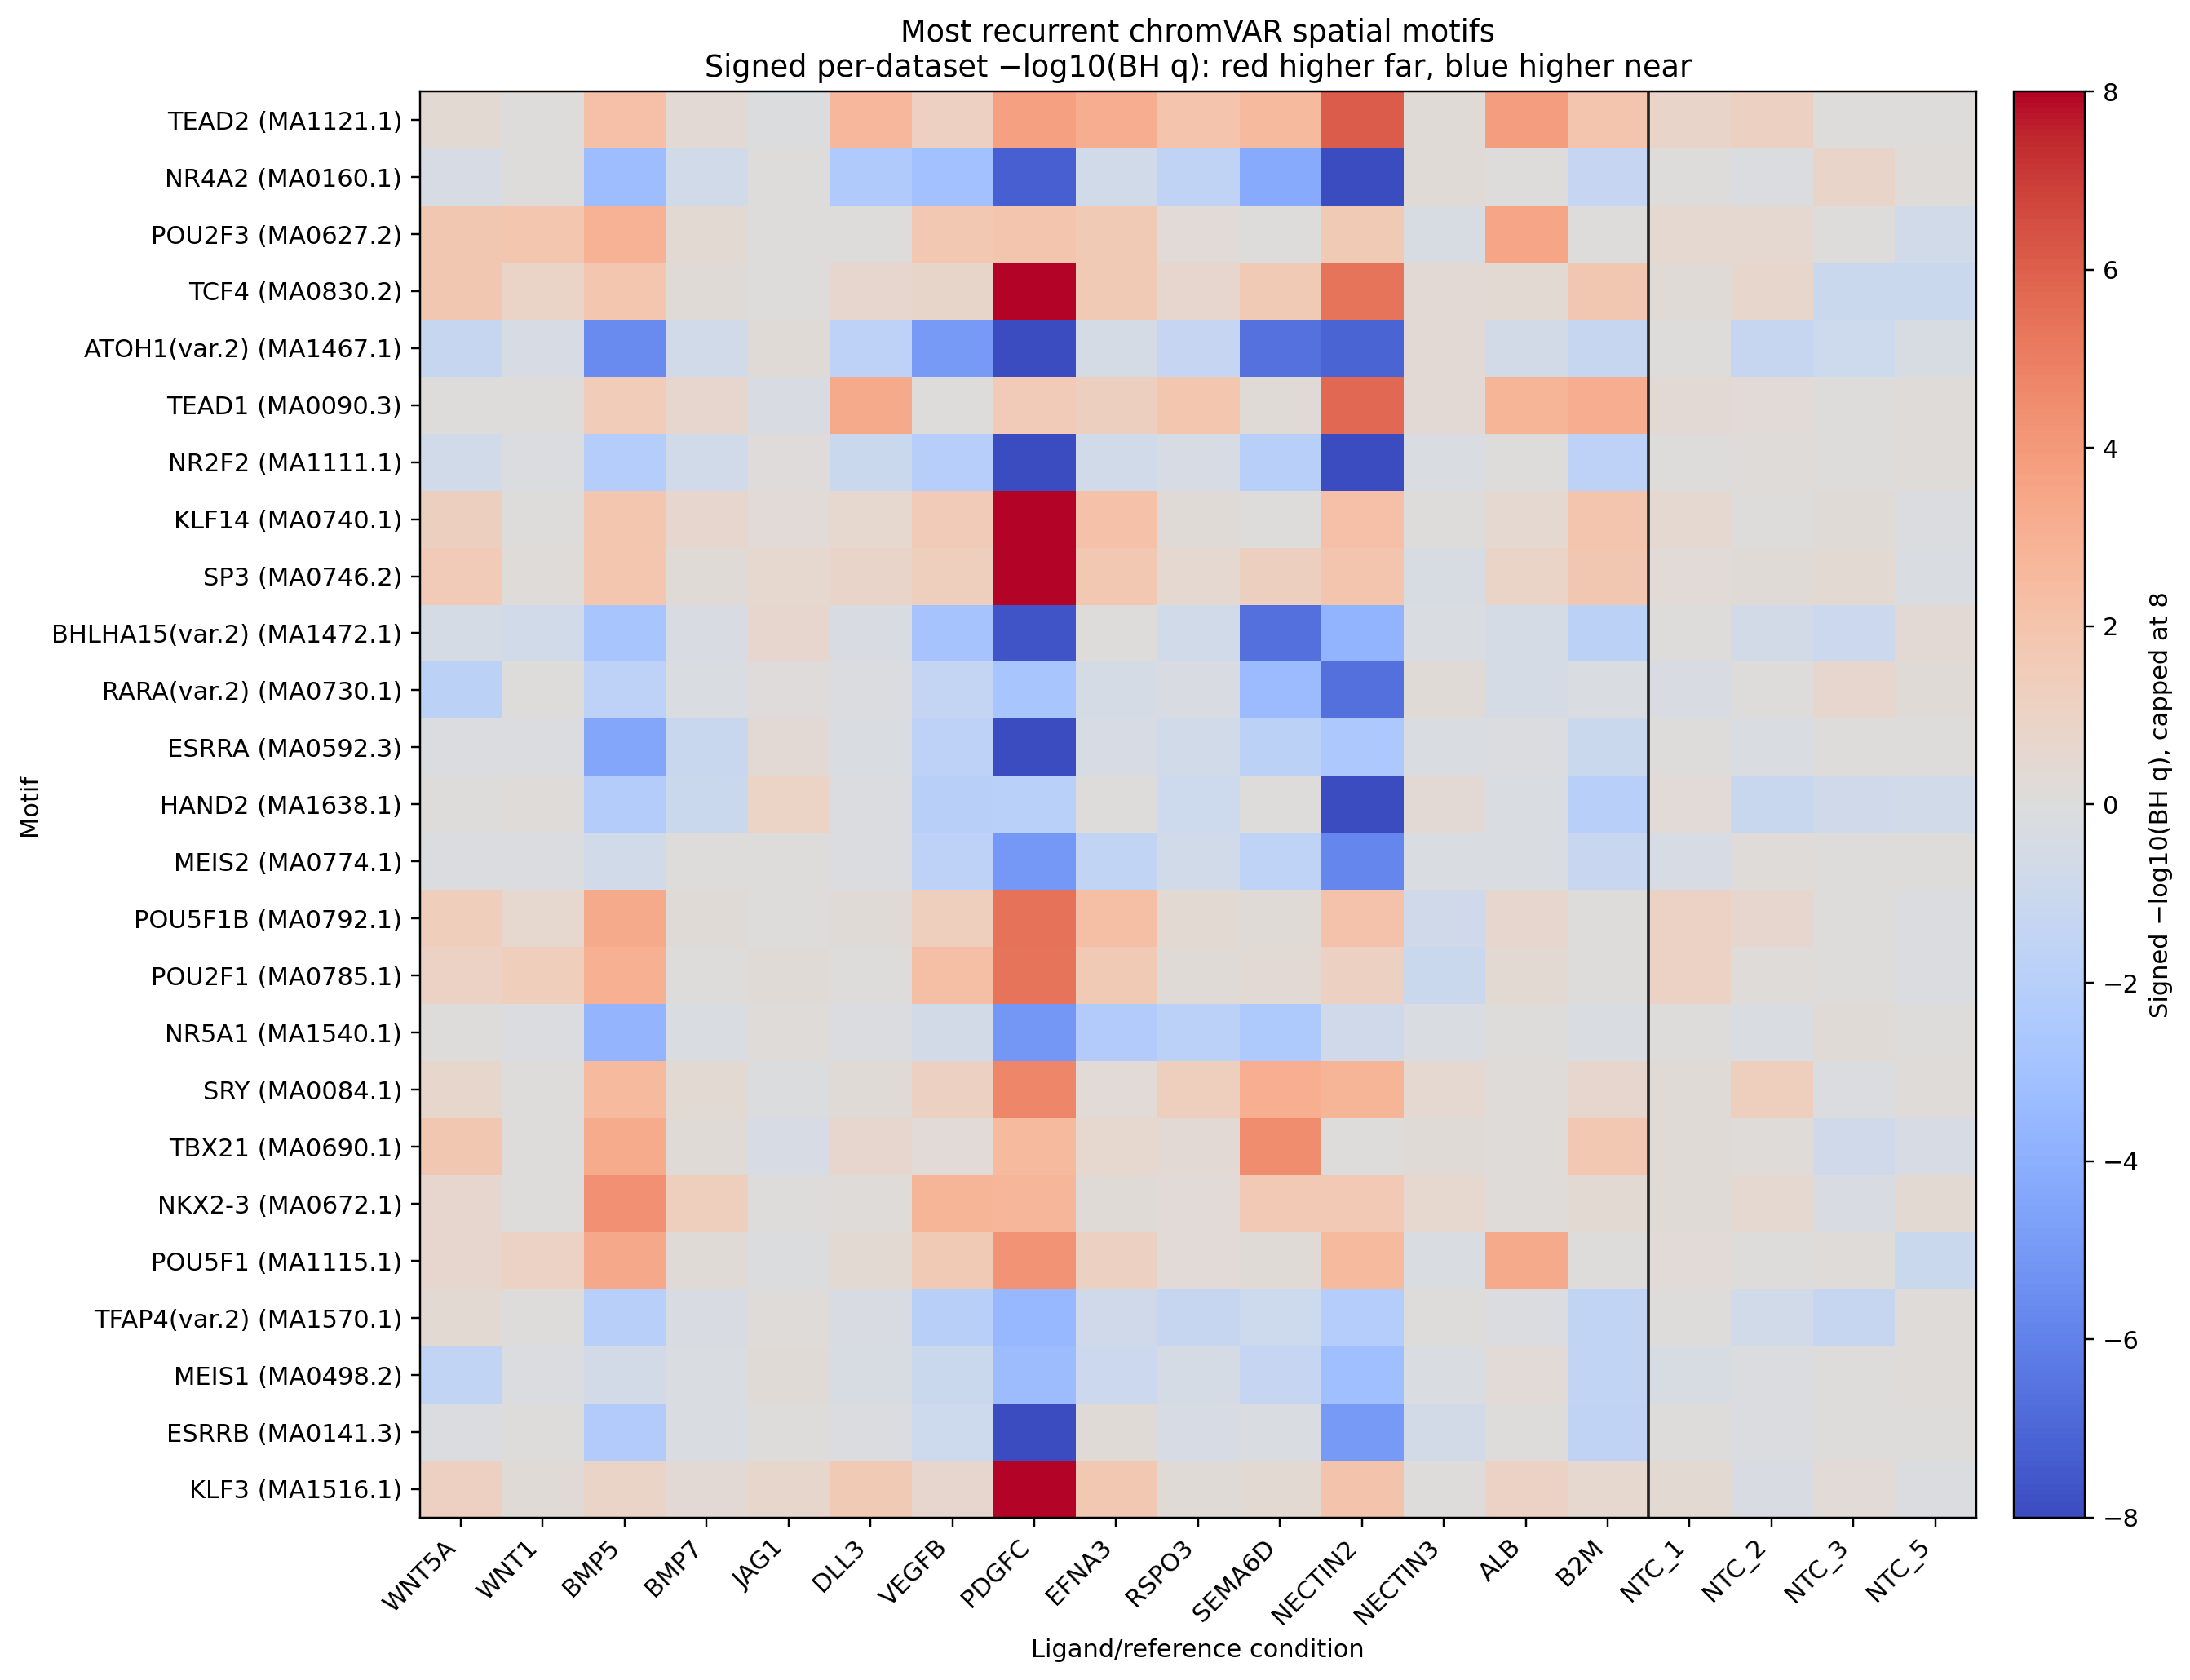

In [11]:
def recurrence_table(combined):
    rows = []
    for motif_id, group in combined.groupby("motif_id", sort=False):
        ligand = group.loc[
            ~bool_series(group["is_negative_control"])
        ]
        control = group.loc[
            bool_series(group["is_negative_control"])
        ]
        ligand_bh = ligand.loc[
            bool_series(ligand["significant_fdr"])
        ]
        control_bh = control.loc[
            bool_series(control["significant_fdr"])
        ]
        directions = np.sign(
            ligand_bh["far_minus_near_chromvar"].to_numpy(float)
        )
        consistent = (
            directions.size > 0
            and np.all(directions != 0)
            and np.unique(directions).size == 1
        )
        rows.append(
            {
                "motif_id": motif_id,
                "motif_name": str(group["motif_name"].iloc[0]),
                "motif_label": str(group["motif_label"].iloc[0]),
                "ligand_bh_count": int(ligand_bh.shape[0]),
                "negative_control_bh_count": int(control_bh.shape[0]),
                "minimum_ligand_bh_q": float(
                    ligand["fdr_q_value"].min()
                ),
                "recurrent_ligand_associated": bool(
                    ligand_bh.shape[0] >= 2
                    and consistent
                    and control_bh.empty
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(
        [
            "recurrent_ligand_associated",
            "ligand_bh_count",
            "negative_control_bh_count",
            "minimum_ligand_bh_q",
        ],
        ascending=[False, False, True, True],
        kind="mergesort",
    )


recurrence_path = RESULTS_ROOT / "motif_recurrence_summary.tsv"
recurrence = (
    pd.read_csv(recurrence_path, sep="\t")
    if recurrence_path.is_file() and not FORCE_RECOMPUTE
    else recurrence_table(combined)
)
recurrent_count = int(
    bool_series(recurrence["recurrent_ligand_associated"]).sum()
)
control_bh_ids = set(
    combined.loc[
        bool_series(combined["is_negative_control"])
        & bool_series(combined["significant_fdr"]),
        "motif_id",
    ].astype(str)
)
print(f"Recurrent ligand-associated motifs: {recurrent_count}")
print(f"Distinct motifs BH-significant in any NTC: {len(control_bh_ids)}")

existing_heatmap = RESULTS_ROOT / "recurrent_motif_heatmap.png"
if existing_heatmap.is_file() and not FORCE_RECOMPUTE:
    display(Image(filename=str(existing_heatmap)))
else:
    selected = recurrence.head(25)
    motif_order = selected["motif_id"].astype(str).tolist()
    dataset_order = [item.dataset for item in CONDITIONS]
    matrix = np.full((25, 19), np.nan)
    for row_index, motif_id in enumerate(motif_order):
        motif_rows = combined.loc[
            combined["motif_id"].astype(str) == motif_id
        ].set_index("dataset")
        for column_index, dataset in enumerate(dataset_order):
            record = motif_rows.loc[dataset]
            strength = min(
                -np.log10(max(float(record["fdr_q_value"]), 1e-12)),
                8,
            )
            matrix[row_index, column_index] = (
                np.sign(float(record["far_minus_near_chromvar"]))
                * strength
            )
    figure, axis = plt.subplots(figsize=(13, 9))
    image = axis.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="coolwarm",
        vmin=-8,
        vmax=8,
    )
    axis.set_yticks(
        np.arange(25), selected["motif_label"].astype(str)
    )
    axis.set_xticks(
        np.arange(19), dataset_order, rotation=45, ha="right"
    )
    axis.axvline(14.5, color="#222222", linewidth=1.2)
    axis.set_title(
        "Most recurrent chromVAR spatial motifs\n"
        "Signed −log10(BH q): red higher far, blue higher near"
    )
    figure.colorbar(image, ax=axis, pad=0.02).set_label(
        "Signed −log10(BH q), capped at 8"
    )
    figure.tight_layout()
    figure.savefig(
        OUTPUT_DIR / "recurrent_motif_heatmap.png",
        dpi=220,
        bbox_inches="tight",
    )
    display(figure)
    plt.close(figure)


## 7. Reproducibility checks

Structural properties are hard assertions. Exact discovery counts are
compared with the accepted reference run only when the source SHA-256
matches; they are reported as comparisons rather than universal
invariants because borderline optimization results can vary slightly
across BLAS/platform builds.


In [12]:
EXPECTED_WITHIN_CONDITION = {
    "WNT5A": (78, 7),
    "WNT1": (14, 4),
    "BMP5": (136, 62),
    "BMP7": (30, 4),
    "JAG1": (1, 0),
    "DLL3": (24, 7),
    "VEGFB": (66, 29),
    "PDGFC": (242, 173),
    "EFNA3": (97, 28),
    "RSPO3": (31, 11),
    "SEMA6D": (94, 46),
    "NECTIN2": (200, 140),
    "NECTIN3": (11, 0),
    "ALB": (15, 8),
    "B2M": (123, 58),
    "NTC_1": (30, 2),
    "NTC_2": (66, 23),
    "NTC_3": (33, 9),
    "NTC_5": (50, 26),
}
observed = batch_summary.set_index("dataset")
comparison_rows = []
for dataset, (expected_bh, expected_by) in EXPECTED_WITHIN_CONDITION.items():
    observed_bh = int(
        observed.loc[dataset, "bh_fdr_0_05_motif_count"]
    )
    observed_by = int(
        observed.loc[dataset, "by_fdr_0_05_motif_count"]
    )
    comparison_rows.append(
        {
            "dataset": dataset,
            "observed_BH": observed_bh,
            "reference_BH": expected_bh,
            "BH_match": observed_bh == expected_bh,
            "observed_BY": observed_by,
            "reference_BY": expected_by,
            "BY_match": observed_by == expected_by,
        }
    )
comparison = pd.DataFrame(comparison_rows)

assert combined.shape[0] == 19 * 633
assert int(batch_summary["tested_motif_count"].sum()) == 19 * 633
assert int(batch_summary["fit_failure_count"].sum()) == 0
assert (
    pd.to_numeric(combined["rbf_lengthscale_um"], errors="raise").min()
    >= RBF_LENGTHSCALE_MINIMUM_UM
)
assert set(batch_summary["dataset"]) == set(EXPECTED_WITHIN_CONDITION)
if source_sha256 == REFERENCE_SOURCE_SHA256:
    if not comparison[["BH_match", "BY_match"]].to_numpy().all():
        warnings.warn(
            "The source matches, but one or more exact discovery counts "
            "differ from the pinned reference. Inspect optimizer and BLAS "
            "versions for borderline fits."
        )

is_control = bool_series(batch_summary["is_negative_control"])
ligand_bh_sum = int(
    batch_summary.loc[
        ~is_control, "bh_fdr_0_05_motif_count"
    ].sum()
)
ligand_by_sum = int(
    batch_summary.loc[
        ~is_control, "by_fdr_0_05_motif_count"
    ].sum()
)
control_bh_sum = int(
    batch_summary.loc[
        is_control, "bh_fdr_0_05_motif_count"
    ].sum()
)
control_by_sum = int(
    batch_summary.loc[
        is_control, "by_fdr_0_05_motif_count"
    ].sum()
)
floor_total = int(
    batch_summary["lengthscale_at_minimum_count"].sum()
)
floor_significant = int(
    batch_summary[
        "significant_lengthscale_at_minimum_count"
    ].sum()
)
summary = pd.DataFrame(
    {
        "quantity": [
            "Completed motif fits",
            "Fit failures",
            "Minimum fitted RBF lengthscale",
            "Fits at the 25 µm floor",
            "BH-significant fits at the floor",
            "Sum of within-ligand BH discoveries",
            "Sum of within-ligand BY discoveries",
            "Sum of within-NTC BH discoveries",
            "Sum of within-NTC BY discoveries",
            "Recurrent ligand-associated motifs",
        ],
        "observed": [
            combined.shape[0],
            int(batch_summary["fit_failure_count"].sum()),
            float(combined["rbf_lengthscale_um"].min()),
            floor_total,
            floor_significant,
            ligand_bh_sum,
            ligand_by_sum,
            control_bh_sum,
            control_by_sum,
            recurrent_count,
        ],
        "accepted_reference": [
            12027,
            0,
            "≥25 µm",
            1014,
            162,
            1162,
            577,
            179,
            60,
            134,
        ],
    }
)
display(summary)
display(comparison)


,quantity,observed,accepted_reference
0,Completed motif fits,12027.0,12027
1,Fit failures,0.0,0
2,Minimum fitted RBF lengthscale,25.0,≥25 µm
3,Fits at the 25 µm floor,1014.0,1014
4,BH-significant fits at the floor,162.0,162
5,Sum of within-ligand BH discoveries,1162.0,1162
6,Sum of within-ligand BY discoveries,577.0,577
7,Sum of within-NTC BH discoveries,179.0,179
8,Sum of within-NTC BY discoveries,60.0,60
9,Recurrent ligand-associated motifs,134.0,134


,dataset,observed_BH,reference_BH,BH_match,observed_BY,reference_BY,BY_match
0,WNT5A,78,78,True,7,7,True
1,WNT1,14,14,True,4,4,True
2,BMP5,136,136,True,62,62,True
3,BMP7,30,30,True,4,4,True
4,JAG1,1,1,True,0,0,True
5,DLL3,24,24,True,7,7,True
6,VEGFB,66,66,True,29,29,True
7,PDGFC,242,242,True,173,173,True
8,EFNA3,97,97,True,28,28,True
9,RSPO3,31,31,True,11,11,True


In [13]:
packages = [
    "numpy",
    "scipy",
    "pandas",
    "matplotlib",
    "h5py",
    "GPy",
    "paramz",
    "joblib",
]
versions = []
for package in packages:
    try:
        version = importlib_metadata.version(package)
    except importlib_metadata.PackageNotFoundError:
        version = "not installed"
    versions.append({"package": package, "version": version})

run_signature = {
    "source_h5mu_sha256": source_sha256,
    "conditions": [item.dataset for item in CONDITIONS],
    "query_policy": "assigned_non_reference",
    "distance_scope": "within embryoid body only",
    "bin_width_um": BIN_WIDTH_UM,
    "distance_bins": N_BINS,
    "maximum_distance_um": MAX_DISTANCE_UM,
    "motif_count": 633,
    "score_transform": "none",
    "fixed_noise": "mean of squared bin-specific SEMs per motif",
    "null_kernel": "GPy Bias",
    "alternative_kernel": "GPy RBF",
    "rbf_initial_lengthscales_um": RBF_STARTS_UM,
    "rbf_lengthscale_minimum_um": RBF_LENGTHSCALE_MINIMUM_UM,
    "max_optimizer_iters": MAX_OPTIMIZER_ITERS,
    "primary_p_value": "0.5 * chi2.sf(LR, 1) for LR > 0",
    "primary_fdr": "BH separately within each condition",
    "fdr_threshold": FDR_THRESHOLD,
    "top_fit_interval": "95% posterior predictive interval",
    "platform": platform.platform(),
    "python": sys.version.split()[0],
}
display(pd.DataFrame(versions))
display(pd.DataFrame(run_signature.items(), columns=["setting", "value"]))


,package,version
0,numpy,1.26.4
1,scipy,1.12.0
2,pandas,2.2.3
3,matplotlib,3.10.0
4,h5py,3.16.0
5,GPy,1.13.2
6,paramz,0.9.6
7,joblib,1.5.3


,setting,value
0,source_h5mu_sha256,b2baffb8c86e359ad4f3242f36f296fa3911f892fb0bda...
1,conditions,"[WNT5A, WNT1, BMP5, BMP7, JAG1, DLL3, VEGFB, P..."
2,query_policy,assigned_non_reference
3,distance_scope,within embryoid body only
4,bin_width_um,10.0
5,distance_bins,30
6,maximum_distance_um,300.0
7,motif_count,633
8,score_transform,none
9,fixed_noise,mean of squared bin-specific SEMs per motif
